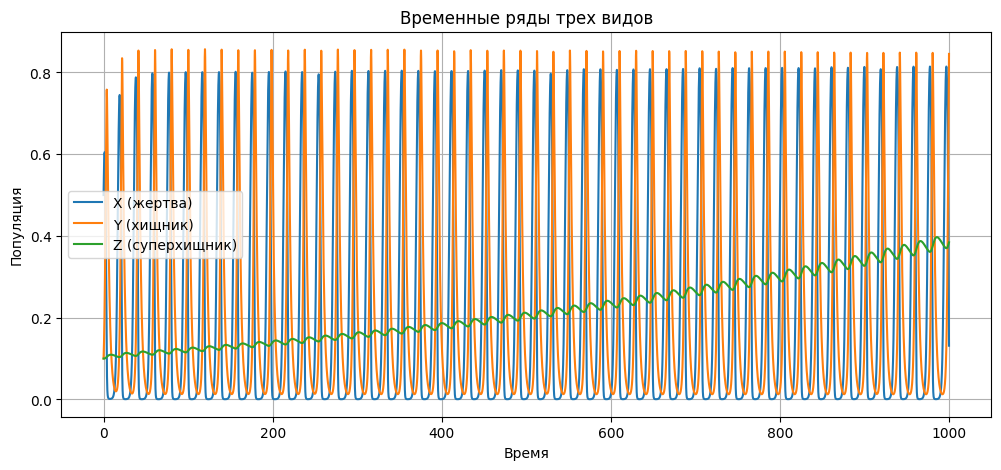

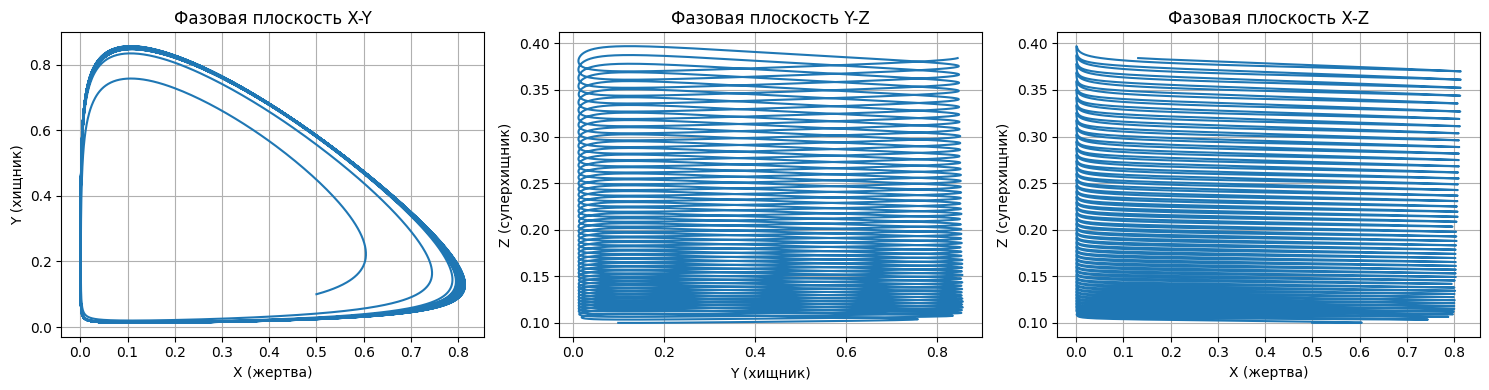

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


r = 1.0     
K = 1.0      
a1 = 5.0    
b1 = 3.0     
a2 = 0.1     
b2 = 2.0     
d1 = 0.4     
d2 = 0.01    

def hasting_powell(t, pop):
    X, Y, Z = pop
    dXdt = r*X*(1 - X/K) - (a1*X*Y)/(1 + b1*X)
    dYdt = (a1*X*Y)/(1 + b1*X) - (a2*Y*Z)/(1 + b2*Y) - d1*Y
    dZdt = (a2*Y*Z)/(1 + b2*Y) - d2*Z
    return [dXdt, dYdt, dZdt]


X0, Y0, Z0 = 0.5, 0.1, 0.1
y0 = [X0, Y0, Z0]

t_span = (0, 1000)
t_eval = np.linspace(t_span[0], t_span[1], 50000)


sol = solve_ivp(hasting_powell, t_span, y0, t_eval=t_eval, method='RK45')


plt.figure(figsize=(12,5))
plt.plot(sol.t, sol.y[0], label='X (жертва)')
plt.plot(sol.t, sol.y[1], label='Y (хищник)')
plt.plot(sol.t, sol.y[2], label='Z (суперхищник)')
plt.xlabel('Время')
plt.ylabel('Популяция')
plt.title('Временные ряды трех видов')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(sol.y[0], sol.y[1])
plt.xlabel('X (жертва)')
plt.ylabel('Y (хищник)')
plt.title('Фазовая плоскость X-Y')
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(sol.y[1], sol.y[2])
plt.xlabel('Y (хищник)')
plt.ylabel('Z (суперхищник)')
plt.title('Фазовая плоскость Y-Z')
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(sol.y[0], sol.y[2])
plt.xlabel('X (жертва)')
plt.ylabel('Z (суперхищник)')
plt.title('Фазовая плоскость X-Z')
plt.grid(True)

plt.tight_layout()
plt.show()



Из графиков видно, что присутствуют периодические колебания по X и Y.